# MammoLens: Breast Cancer Detection on Mammograms

**Author:** Ibrahim Tamilore Esther

This is the experiment that finally told me why my rebuild had gone wrong. I keep every patient in the partition my first run gave them, add the 228 recovered mammograms to those same partitions, and change nothing else. That separates the effect of the recovered images from the effect of splitting the data again. I call this run v4, and its outputs are in `original_split_with_recovered_images/`.

> `README.md` explains all four runs I did and which one I am reporting as my main result.

> This is an academic prototype. It is not a medical device and it must not be used to make decisions about anyone's care.

<a id="intro"></a>
## Why this experiment

By this point I had three possible explanations for something that made no sense to me: I had given the model more data and it had got worse. My control run in `MammoLens_recovered_data_full_schedule.ipynb` ruled the first one out. With early stopping switched off, the model reached a training AUC of 0.9783, which is essentially where my first run sat at 0.9792, and its test AUC moved by only +0.0067 with a 95% interval of [-0.0307, +0.0405]. So it was not that I had stopped training too soon.

That left two explanations, and in v2 and v3 they are tangled together, because those runs changed the data and the split at the same time. The new split gave me partitions that are less even than my original ones, with a validation set at 38.7% malignant against a test set at 46.3%, and it also moved patients around. Separately, the 228 recovered images brought in 105 patients that none of my earlier runs had ever seen.

Here I hold the split as close to my first one as the new data allow. Every patient stays where v1 put them, each recovered image goes into its own patient's partition, and only the 105 genuinely new patients get assigned afresh, using the same stratified rule and the same seed I have used throughout. Then I train with the identical recipe for the full 12 epochs.

I decided how to read the outcome before I ran it. If v4 lands close to v1, the problem was the re-split. If it lands close to v3, the problem was the recovered images or the patients they brought with them. If it lands somewhere in the middle, I say so and leave it there rather than talking myself into an answer.

One thing to keep in mind throughout: my v4 test set is built out of v1's, so the two share most of their images and are not independent samples. And every run here is a single training run, so none of this is a repeated measurement.

<a id="contents"></a>
## Contents

- [1 Setup and guards](#s1)
- [2 Building the v4 split](#s2)
- [3 Training](#s3)
  - [3.1 Twelve epochs, no early stopping](#s3-1)
  - [3.2 Training log and learning curve](#s3-2)
- [4 Evaluation](#s4)
  - [4.1 Per-image predictions](#s4-1)
  - [4.2 Discrimination by split](#s4-2)
  - [4.3 Density strata and bootstrap intervals](#s4-3)
  - [4.4 Testing the density gap](#s4-4)
  - [4.5 Operating points and calibration](#s4-5)
  - [4.6 Grad-CAM gallery](#s4-6)
- [5 Paired comparisons with v1 and v3](#s5)
- [6 Four-way comparison and what it supports](#s6)
- [7 Verification that no earlier artefact was touched](#s7)

Tables: [1](#t1) the v4 split; [2](#t2) training log; [3](#t3) AUC by split; [4](#t4) bootstrap intervals; [5](#t5) gap tests; [6](#t6) operating points; [7](#t7) paired comparisons; [8](#t8) v1, v2, v3 and v4. Figures: [1](#f1) learning curve; [2](#f2) calibration; [3](#f3) Grad-CAM gallery.

<a id="s1"></a>
## 1 Setup and guards

The cell below loads the same configuration file I have used for every run, then points the checkpoint, manifest and results paths at `original_split_with_recovered_images/` so this experiment cannot overwrite anything of mine. It also switches early stopping off, as I did in v3, so the schedule runs to the end.

I then added two guards, because by this stage I had learned to distrust my own file handling. The first reads both sets of manifests, the v1 ones from `initial_run/manifests/` and the v2 ones from `data/`, and checks they still hold the sizes I reported earlier. If someone had rebuilt the split again in between, this comparison would be meaningless and I would rather find out in the first cell than in the conclusion. The second guard records the size and modification time of every file in my three existing run folders, so that Section 7 can show I did not write into any of them.

In [1]:
# v4: my v1 partitions plus the recovered images, trained with the v1 and v3 recipe.
# I write only inside original_split_with_recovered_images/ so my earlier runs stay intact.
import os, sys, copy, json, time, shutil
import numpy as np
import pandas as pd
import torch

IN_COLAB = 'google.colab' in sys.modules
COLAB_ROOT = '/content/drive/MyDrive/MammoLens'
if IN_COLAB:
    if not os.path.isdir('/content/drive/MyDrive'):
        from google.colab import drive
        drive.mount('/content/drive')
    PROJECT_DIR = COLAB_ROOT
else:
    here = os.getcwd()
    PROJECT_DIR = os.path.dirname(here) if os.path.basename(here) == 'notebooks' else here
os.chdir(PROJECT_DIR)
if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

from src.config import load_config, ensure_dirs
cfg4 = load_config('configs/config.yaml')
if not IN_COLAB:
    for k, v in vars(cfg4.paths).items():
        setattr(cfg4.paths, k, v.replace(COLAB_ROOT, PROJECT_DIR))

RUN4 = os.path.join(PROJECT_DIR, 'original_split_with_recovered_images')
RES4, CKPT4, FIG4, MAN4 = (os.path.join(RUN4, d) for d in ('results', 'checkpoints', 'figures', 'manifests'))
for p in (RES4, CKPT4, FIG4, MAN4):
    os.makedirs(p, exist_ok=True)
cfg4.paths.checkpoint_dir = CKPT4
cfg4.paths.log_dir = os.path.join(RES4, 'logs')
for s in ('train', 'val', 'test'):
    setattr(cfg4.paths, f'{s}_csv', os.path.join(MAN4, f'{s}.csv'))   # v4 manifests, written in Section 2
cfg4.train.early_stopping_patience = 10 ** 6                          # as in v3, so the schedule finishes
ensure_dirs(cfg4)

RUN1 = os.path.join(PROJECT_DIR, 'initial_run')
RUN2 = os.path.join(PROJECT_DIR, 'recovered_data_run')
RUN3 = os.path.join(PROJECT_DIR, 'recovered_data_full_schedule')
DATA_DIR = cfg4.paths.data_dir
LOCAL_DATA = '/content/data' if IN_COLAB else os.path.join(PROJECT_DIR, 'local_cache')
IMG_ROOT = DATA_DIR            # the training cell repoints this at the local copy in Colab
SEED, POS = cfg4.project.seed, cfg4.evaluate.positive_class
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# If the split had been rebuilt since v2, this experiment would mean nothing,
# so I read both sets of manifests and check the sizes before anything else.
V1 = {s: pd.read_csv(os.path.join(RUN1, 'manifests', f'{s}.csv')) for s in ('train', 'val', 'test')}
V2 = {s: pd.read_csv(os.path.join(DATA_DIR, f'{s}.csv')) for s in ('train', 'val', 'test')}
print('v1 split:', {s: len(d) for s, d in V1.items()}, '| total', sum(len(d) for d in V1.values()))
print('v2 split:', {s: len(d) for s, d in V2.items()}, '| total', sum(len(d) for d in V2.values()))

# Fingerprint my earlier runs now so Section 7 can prove I did not write into them.
PROTECTED = ['initial_run', 'recovered_data_run', 'recovered_data_full_schedule', 'data']
def fingerprint():
    out = {}
    for d in PROTECTED:
        root = os.path.join(PROJECT_DIR, d)
        if not os.path.isdir(root):
            continue
        if d == 'data':      # manifests only: walking 10237 jpegs over Drive is far too slow
            entries = [(root, [f for f in os.listdir(root) if os.path.isfile(os.path.join(root, f))])]
        else:
            entries = [(dp, fs) for dp, _, fs in os.walk(root)]
        for dirpath, files in entries:
            for f in files:
                p = os.path.join(dirpath, f)
                out[os.path.relpath(p, PROJECT_DIR)] = (os.path.getsize(p), round(os.path.getmtime(p), 3))
    return out
BEFORE = fingerprint()
print(f'\nFingerprinted {len(BEFORE)} files across the three existing run folders.')
print(f'Device: {device}' + (f' ({torch.cuda.get_device_name(0)})' if device.type == 'cuda' else ''))
print(f'Epochs: {cfg4.train.epochs} | early stopping: disabled | seed: {SEED} | '
      f'batch {cfg4.train.batch_size} | lr {cfg4.train.learning_rate} | image size {cfg4.data.image_size}')

Mounted at /content/drive
v1 split: {'train': 2052, 'val': 405, 'test': 400} | total 2857
v2 split: {'train': 2210, 'val': 445, 'test': 430} | total 3085

Fingerprinted 50 files across the three existing run folders.
Device: cuda (Tesla T4)
Epochs: 12 | early stopping: disabled | seed: 42 | batch 32 | lr 0.0003 | image size 224


Both manifests loaded with the sizes I expected, 2857 images for v1 and 3085 for v2, and the fingerprint covered 50 files across my three earlier run folders. The run went on a Tesla T4 with early stopping disabled, 12 epochs, seed 42, batch size 32, a learning rate of 0.0003 and 224-pixel inputs. Those are v1's and v3's settings, untouched.

<a id="s2"></a>
## 2 Building the v4 split

To find the recovered images I take the difference between the two manifests: anything in the v2 manifests that is not in the v1 manifests. I expect 228 of them, which is what the rebuild left after I dropped 16 duplicate views.

Each one then goes where the rule says. If its patient is already somewhere in my v1 split, the image joins that same partition. That keeps the patient grouping intact and, more importantly, leaves my original assignment completely alone. If the patient is new, and 105 of them were missing from v1 altogether, then the patient gets assigned the way I have assigned patients all along: `StratifiedGroupKFold` with seed 42, grouped on patient and stratified on the joint label and density key, taking fold 0 of a 7-fold split as test and fold 0 of a 6-fold split of the rest as validation. Running that on the new patients alone keeps the overall proportions near 70/15/15 without disturbing anyone v1 had already placed.

That rule needs enough patients in each stratum to make seven folds, and with only 105 patients it might not get them. If it fails, the cell falls back to a seeded round-robin over patients that preserves the same proportions, and it prints which route it took. I wanted that printed rather than silent, because a fallback I did not notice would be worse than one I can see.

The cell finishes by checking that no patient ended up in more than one partition, and by comparing my v4 and v1 test sets image by image. That overlap matters for Section 5: because v4 starts from v1's assignment, the two test sets share most of their images, which makes the comparison between those two runs informative but not independent.

In [2]:
# STEP 1: keep my v1 partitions, and drop each recovered image into its own patient's partition.
from sklearn.model_selection import StratifiedGroupKFold

v1_all = pd.concat([d.assign(split=s) for s, d in V1.items()], ignore_index=True)
v2_all = pd.concat([d.assign(split=s) for s, d in V2.items()], ignore_index=True)
recovered = v2_all[~v2_all['image_path'].isin(set(v1_all['image_path']))].reset_index(drop=True)
print(f'Images in v1: {len(v1_all)} | in v2: {len(v2_all)} | recovered (v2 not in v1): {len(recovered)}')

pat2split = dict(zip(v1_all['patient_id'], v1_all['split']))
recovered['existing_split'] = recovered['patient_id'].map(pat2split)
joins_existing = recovered['existing_split'].notna()
new_pat = recovered.loc[~joins_existing].copy()
print(f'  joining a patient v1 already placed: {int(joins_existing.sum())} images '
      f'({recovered.loc[joins_existing, "patient_id"].nunique()} patients)')
print(f'  belonging to patients new in v2:     {len(new_pat)} images '
      f'({new_pat["patient_id"].nunique()} patients)')

# New patients only: the project's standard grouped, stratified assignment.
route = 'StratifiedGroupKFold (seed 42)'
if len(new_pat):
    new_pat['strat'] = new_pat['label'].astype(str) + '_' + new_pat['density'].astype(str)
    def holdout(frame, n_splits):
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
        keep, hold = next(sgkf.split(frame, frame['strat'], frame['patient_id']))
        return frame.iloc[keep].reset_index(drop=True), frame.iloc[hold].reset_index(drop=True)
    try:
        trainval, test_new = holdout(new_pat, 7)
        train_new, val_new = holdout(trainval, 6)
        assign = {'train': train_new, 'val': val_new, 'test': test_new}
    except Exception as exc:                       # too few patients in a stratum to make 7 folds
        route = f'seeded round-robin over patients (StratifiedGroupKFold failed: {exc})'
        rng = np.random.default_rng(SEED)
        pats = new_pat['patient_id'].drop_duplicates().to_numpy()
        rng.shuffle(pats)
        shares = {'train': 0.70, 'val': 0.15, 'test': 0.15}
        cuts = np.cumsum([int(round(len(pats) * shares[k])) for k in ('train', 'val')])
        groups = {'train': set(pats[:cuts[0]]), 'val': set(pats[cuts[0]:cuts[1]]), 'test': set(pats[cuts[1]:])}
        assign = {k: new_pat[new_pat['patient_id'].isin(v)] for k, v in groups.items()}
else:
    assign = {k: new_pat for k in ('train', 'val', 'test')}
print(f'New patients assigned by: {route}')

COLS = ['image_path', 'label', 'density', 'patient_id']
V4 = {}
for s in ('train', 'val', 'test'):
    parts = [V1[s][COLS],
             recovered.loc[joins_existing & (recovered['existing_split'] == s), COLS],
             assign[s][COLS] if len(assign[s]) else pd.DataFrame(columns=COLS)]
    V4[s] = pd.concat(parts, ignore_index=True)
    V4[s].to_csv(os.path.join(MAN4, f'{s}.csv'), index=False)
V4 = {s: pd.read_csv(os.path.join(MAN4, f'{s}.csv')) for s in ('train', 'val', 'test')}
total4 = sum(len(d) for d in V4.values())
assert total4 == len(v1_all) + len(recovered), 'images lost or duplicated while building the split'

print(f'\nv4 split of {total4} images (v1 had {len(v1_all)}):')
for s, d in V4.items():
    vc = d['label'].value_counts()
    print(f'  {s:<5} {len(d):5d} images ({len(d) / total4:5.1%}), {d["patient_id"].nunique():4d} patients, '
          f'malignant {int(vc.get(1, 0)):4d} ({vc.get(1, 0) / len(d):5.1%})')
print('\nDensity balance (percentage within each split):')
print((pd.DataFrame({s: d['density'].value_counts(normalize=True) for s, d in V4.items()})
       .reindex([1, 2, 3, 4]).fillna(0) * 100).round(1).to_string())
print('\nDensity counts:')
print(pd.DataFrame({s: d['density'].value_counts() for s, d in V4.items()})
      .reindex([1, 2, 3, 4]).fillna(0).astype(int).to_string())

ptr, pv, pte = (set(V4[s]['patient_id']) for s in ('train', 'val', 'test'))
assert not (ptr & pv) and not (ptr & pte) and not (pv & pte), 'patient overlap between v4 partitions'
print('\nOK: no patient_id appears in more than one v4 partition.')

t1, t4 = set(V1['test']['image_path']), set(V4['test']['image_path'])
print(f'\nTest sets: v1 {len(t1)} images, v4 {len(t4)} images, shared {len(t1 & t4)}, '
      f'only in v4 {len(t4 - t1)}, only in v1 {len(t1 - t4)}')
print(f'Every v1 test image still in the v4 test set: {t1 <= t4}')

Images in v1: 2857 | in v2: 3085 | recovered (v2 not in v1): 228
  joining a patient v1 already placed: 33 images (26 patients)
  belonging to patients new in v2:     195 images (105 patients)
New patients assigned by: StratifiedGroupKFold (seed 42)


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:1023: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=6.
  warnings.warn(



v4 split of 3085 images (v1 had 2857):
  train  2208 images (71.6%), 1118 patients, malignant  988 (44.7%)
  val     439 images (14.2%),  223 patients, malignant  197 (44.9%)
  test    438 images (14.2%),  224 patients, malignant  179 (40.9%)

Density balance (percentage within each split):
         train   val  test
density                   
1         14.8  11.4  10.3
2         38.3  41.2  39.5
3         29.5  34.4  33.8
4         17.4  13.0  16.4

Density counts:
         train  val  test
density                  
1          326   50    45
2          846  181   173
3          651  151   148
4          385   57    72

OK: no patient_id appears in more than one v4 partition.

Test sets: v1 400 images, v4 438 images, shared 400, only in v4 38, only in v1 0
Every v1 test image still in the v4 test set: True


<a id="t1"></a>
**Table 1.** How the recovered images were assigned, then the v4 split: images, share, patients and malignant count per partition, the density composition, the patient-overlap check, and an image-level comparison of my v4 and v1 test sets.

The recovered set came out at exactly 228 images, which matches the rebuild. Of those, 33 images belong to 26 patients v1 had already placed, so they simply joined their patients' partitions, and 195 come from the 105 patients that were missing from v1. The stratified rule ran rather than the fallback, although scikit-learn warned me that the smallest stratum holds only 3 patients against the 6 folds I asked for, so the assignment in those thin strata is approximate.

What I ended up with is 3085 images: 2208 for training, 439 for validation and 438 for test, or 71.6%, 14.2% and 14.2%, with no patient in more than one partition. The balance is much closer to v1's than to v2's. Malignant shares run 44.7%, 44.9% and 40.9%, so the validation set no longer sits several points below the test set the way it did in v2 (Table 4 of my rebuild notebook). The density mix is steadier too, with BI-RADS 1 at 14.8% of training and 10.3% of test.

The line I was most interested in is the test-set comparison. All 400 of my v1 test images are still in the v4 test set, which now holds 438, and not one v1 test image was lost. That is the design doing what I intended, and it is also why the v1 comparison in Section 5 is a comparison between two models rather than between two samples.

<a id="s3"></a>
## 3 Training

<a id="s3-1"></a>
### 3.1 Twelve epochs, no early stopping

This is the same training call as in v2, with two differences. The patience is set high enough that early stopping cannot fire, and the run is tagged `v4` so it writes its own checkpoints and cannot pick up where another run left off. Everything else, the seed included, comes from the same configuration file: AdamW at a learning rate of 0.0003 with weight decay 0.0001, cosine annealing over 12 epochs, batch size 32, dropout 0.3 before the classifier, mixed precision, unweighted cross-entropy, no class weighting, a random horizontal flip at probability 0.5 with rotation within 10 degrees, inputs of 224 by 224 pixels and seed 42.

I should be clear about one thing: v4 trains on more images than v1 did, so this is not a reproduction of v1. It is v1's split with the recovered data added, which is the only way I could think of to separate the split from the data without throwing the recovered images away again.

In [3]:
# STEP 2: train on my v4 split for the full 12 epochs, tagged v4 so it cannot resume another run.
from src.train import train

if IN_COLAB:                       # copying buys little (I measured it), but keeps the pipeline identical
    from concurrent.futures import ThreadPoolExecutor
    rels = pd.concat([d['image_path'] for d in V4.values()]).unique()
    def _copy(rel):
        dst = os.path.join(LOCAL_DATA, rel)
        if os.path.isfile(dst):
            return 0
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        shutil.copy(os.path.join(DATA_DIR, rel), dst)
        return 1
    with ThreadPoolExecutor(max_workers=8) as ex:
        n_copied = sum(ex.map(_copy, rels))
    print(f'Local copy: {n_copied} copied, {len(rels) - n_copied} already present')
    cfg4.paths.data_dir = LOCAL_DATA
IMG_ROOT = cfg4.paths.data_dir

LOG4 = os.path.join(RES4, 'training_log.csv')
t0 = time.time()
model4 = train(cfg4, run_tag='v4', log_csv=LOG4)
print(f'\nTotal wall-clock time: {(time.time() - t0) / 60:.1f} min')

Local copy: 3085 copied, 0 already present


model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

Epoch 01/12 [train]:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch 01/12 | train loss 2.2160 auc 0.5902 | val loss 1.1579 auc 0.6913 acc 0.6492 | lr 2.95e-04 |  456s  *best


...

Epoch 10/12 | train loss 0.3800 auc 0.9173 | val loss 0.8664 auc 0.7545 acc 0.6925 | lr 2.01e-05 |  475s


Epoch 11/12 [train]:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch 11/12 | train loss 0.3458 auc 0.9290 | val loss 0.8404 auc 0.7641 acc 0.6856 | lr 5.11e-06 |  472s  *best


Epoch 12/12 [train]:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch 12/12 | train loss 0.3429 auc 0.9314 | val loss 0.8659 auc 0.7572 acc 0.6925 | lr 0.00e+00 |  451s
Done. Best val AUC = 0.7641 -> /content/drive/MyDrive/MammoLens/original_split_with_recovered_images/checkpoints/best_model.pt

Total wall-clock time: 92.9 min


All 12 epochs ran. Validation AUC climbed quickly to 0.7344 by epoch 2, then moved about unevenly before reaching 0.7641 at epoch 11 and easing back to 0.7572 at the last epoch, so the checkpoint I keep comes from epoch 11. Training loss fell from 2.2160 to 0.3429 and training AUC reached 0.9314. The whole thing took 92.9 minutes.

That validation figure was my first hint that this experiment would answer the question. v3 trained on the same images with the same recipe and the same full schedule, and peaked at 0.7490. Here I get 0.7641. The only thing I changed was how the images were divided up.

<a id="s3-2"></a>
### 3.2 Training log and learning curve

I read the log back from disk rather than from memory, print it, and put it beside v3's for the epochs they share. Reading from the file means the table describes what was actually saved, which is what I would be resuming from or auditing later.

The figure plots my training and validation AUC with v3's validation curve behind them, so the two runs can be compared directly. My first run left no log at all, which is why v1 cannot appear here; its final validation AUC is quoted in Section 6 instead.

run_tag  epoch train_loss train_auc val_loss val_auc       lr  epoch_seconds
     v4      1     2.2160    0.5902   1.1579  0.6913 3.00e-04          456.1
     v4      2     1.3374    0.6671   0.8428  0.7344 2.95e-04          436.7
     v4      3     0.8860    0.7410   1.0499  0.6939 2.80e-04          437.6
     v4      4     0.7376    0.7839   0.9286  0.7382 2.56e-04          437.0
     v4      5     0.7288    0.7913   0.9121  0.7369 2.25e-04          438.4
     v4      6     0.5531    0.8491   0.8569  0.7458 1.89e-04          434.7
     v4      7     0.5300    0.8664   0.9025  0.7494 1.50e-04          454.4
     v4      8     0.4337    0.8942   0.8851  0.7479 1.11e-04          461.3
     v4      9     0.4093    0.9082   0.8767  0.7610 7.50e-05          485.9
     v4     10     0.3800    0.9173   0.8664  0.7545 4.39e-05          474.8
     v4     11     0.3458    0.9290   0.8404  0.7641 2.01e-05          472.2
     v4     12     0.3429    0.9314   0.8659  0.7572 5.11e-06          451.0

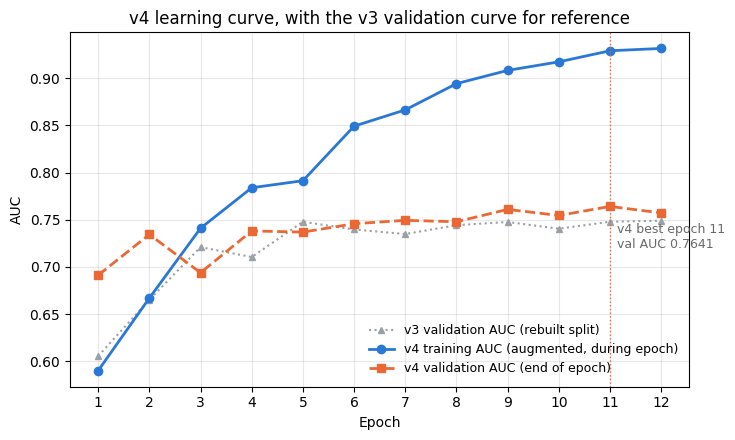

Saved -> /content/drive/MyDrive/MammoLens/original_split_with_recovered_images/figures/training_curve.png


In [4]:
# 3.2 Read my log back from disk, print it, and plot it against v3's.
import matplotlib.pyplot as plt

log4 = pd.read_csv(LOG4)
print(log4.to_string(index=False, formatters={'train_loss': '{:.4f}'.format, 'train_auc': '{:.4f}'.format,
                                              'val_loss': '{:.4f}'.format, 'val_auc': '{:.4f}'.format,
                                              'lr': '{:.2e}'.format}))
best4 = log4.loc[log4['val_auc'].idxmax()]
print(f"\nEpochs completed: {len(log4)} | best validation AUC {best4['val_auc']:.4f} at epoch {int(best4['epoch'])} "
      f"| final epoch {log4['val_auc'].iloc[-1]:.4f}")
print(f"Total training time: {log4['epoch_seconds'].sum() / 60:.1f} min "
      f"({log4['epoch_seconds'].mean():.0f} s per epoch)")

log3 = pd.read_csv(os.path.join(RUN3, 'results', 'training_log.csv'))
best3 = log3.loc[log3['val_auc'].idxmax()]
print(f"v3 for comparison: best validation AUC {best3['val_auc']:.4f} at epoch {int(best3['epoch'])}, "
      f"final epoch {log3['val_auc'].iloc[-1]:.4f}")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(log3['epoch'], log3['val_auc'], color='#9aa0a6', marker='^', linestyle=':', linewidth=1.5,
        markersize=5, label='v3 validation AUC (rebuilt split)')
ax.plot(log4['epoch'], log4['train_auc'], color='#2a78d6', marker='o', linewidth=2, markersize=6,
        label='v4 training AUC (augmented, during epoch)')
ax.plot(log4['epoch'], log4['val_auc'], color='#eb6834', marker='s', linestyle='--', linewidth=2,
        markersize=6, label='v4 validation AUC (end of epoch)')
ax.axvline(int(best4['epoch']), color='#eb6834', linestyle=':', linewidth=1)
ax.annotate(f"v4 best epoch {int(best4['epoch'])}\nval AUC {best4['val_auc']:.4f}",
            xy=(int(best4['epoch']), best4['val_auc']), xytext=(5, -30), textcoords='offset points',
            fontsize=9, color='dimgray')
ax.set_xlabel('Epoch'); ax.set_ylabel('AUC'); ax.set_xticks(log4['epoch'])
ax.set_title('v4 learning curve, with the v3 validation curve for reference')
ax.legend(loc='lower right', fontsize=9, frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()
out = os.path.join(FIG4, 'training_curve.png')
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved ->', out)

<a id="t2"></a>
**Table 2.** My per-epoch log for v4: training and validation loss and AUC, the learning rate used in each epoch and how long it took, with v3's best and final validation AUC underneath for comparison.

<a id="f1"></a>
**Figure 1.** Training and validation AUC per epoch for v4, with v3's validation curve in grey. The dotted line marks the epoch I kept as `best_model.pt`. Saved as `original_split_with_recovered_images/figures/training_curve.png`.

Figure 1 shows a validation curve sitting above v3's for most of the run, and a training curve doing what it does in every run of mine: climbing to 0.9314 while validation settles around 0.75. The overfitting is the same as before. What changed is the level validation settles at.

Epochs took between 435 and 486 seconds, so 90.7 minutes of training at an average of 453 seconds per epoch, which is in line with v3's 464. That cost is almost all image loading rather than anything to do with the model, as I found when I measured it in Section 5.6.4 of the rebuild notebook.

<a id="s4"></a>
## 4 Evaluation

<a id="s4-1"></a>
### 4.1 Per-image predictions

I repeat Sections 5.6 and 5.7 of my rebuild notebook here without changing anything, so that every number lines up with the earlier runs. All three splits are scored in evaluation mode with no augmentation, and the malignant probabilities go to `original_split_with_recovered_images/results/`.

I score two models rather than one. The selected checkpoint is the model an ordinary run would keep, and it is the one all my comparison tables use. The final-epoch model is what finishing the schedule actually produces. In v3 those two turned out to be the same file, but I cannot assume that, so I report both and nobody has to guess which one I meant.

In [5]:
# 4.1 Score both checkpoints, the one validation selected and the final epoch, on all three splits.
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, confusion_matrix
from src.data import build_transforms
from src.model import build_model

class EvalImages(Dataset):
    def __init__(self, df, root, image_size):
        self.paths = df['image_path'].tolist()
        self.root = root
        self.tf = build_transforms(image_size, train=False)
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        with Image.open(os.path.join(self.root, self.paths[i])) as im:
            return self.tf(im.convert('RGB'))

mcfg = copy.deepcopy(cfg4)
mcfg.model.pretrained = False

@torch.no_grad()
def score(ckpt_path, df, root=None):
    ck = torch.load(ckpt_path, map_location=device, weights_only=False)
    net = build_model(mcfg).to(device)
    net.load_state_dict(ck['model_state'])
    net.eval()
    loader = DataLoader(EvalImages(df, root or IMG_ROOT, cfg4.data.image_size), batch_size=64,
                        shuffle=False, num_workers=cfg4.data.num_workers)
    p = np.concatenate([torch.softmax(net(x.to(device)).float(), 1)[:, POS].cpu().numpy() for x in loader])
    return df.assign(prob_malignant=p)[['patient_id', 'label', 'prob_malignant', 'density', 'image_path']], ck

PRED4, PRED4_FINAL = {}, {}
for tag, ckpt, store, suffix in (('selected (best val AUC)', os.path.join(CKPT4, 'best_model.pt'), PRED4, ''),
                                 ('final epoch', os.path.join(CKPT4, 'last_checkpoint.pt'), PRED4_FINAL, '_final')):
    ep = None
    for split in ('test', 'train', 'val'):
        store[split], ck = score(ckpt, V4[split])
        ep = ck['epoch'] + 1
        store[split].to_csv(os.path.join(RES4, f'{split}_predictions{suffix}.csv'), index=False)
    print(f'{tag}: epoch {ep}, stored val_auc {ck["best_auc"]:.4f} -> results/*_predictions{suffix}.csv')

te = PRED4['test']
auc_te = roc_auc_score(te['label'], te['prob_malignant'])
tn, fp, fn, tp = confusion_matrix(te['label'], (te['prob_malignant'] >= 0.5).astype(int), labels=[0, 1]).ravel()
print(f"\nTest set: {len(te)} images, {int(te['label'].sum())} malignant")
print(f'Selected model test AUC: {auc_te:.4f} | confusion at 0.5: TN {tn} FP {fp} FN {fn} TP {tp}')

selected (best val AUC): epoch 11, stored val_auc 0.7641 -> results/*_predictions.csv
final epoch: epoch 12, stored val_auc 0.7641 -> results/*_predictions_final.csv

Test set: 438 images, 179 malignant
Selected model test AUC: 0.7527 | confusion at 0.5: TN 182 FP 77 FN 65 TP 114


The selected checkpoint is from epoch 11 and the final-epoch one from epoch 12, so this time they really are different models. On the 438 test images the selected model reached an AUC of 0.7527, with 182 true negatives, 77 false positives, 65 false negatives and 114 true positives at a threshold of 0.5.

That single number is the point of the whole experiment. My first run scored 0.7541 on its own test set and v3 scored 0.6694 on the rebuilt one. This run, trained on the complete dataset but with my original partitions, sits 0.0014 from v1 and 0.0833 above v3.

<a id="s4-2"></a>
### 4.2 Discrimination by split

Table 3 gives AUC on the three splits to four decimal places, with v1, v2 and v3 next to it. v1 and v3 are the two poles of this experiment: v1 is the run whose split I inherited, and v3 is the run whose data I share. Where v4 falls between them is my answer.

The v1 and v2 columns are measured on their own splits, which are not mine, so they cannot be compared image for image. I deal with that properly in Section 5 using paired comparisons on shared images.

In [6]:
# 4.2 AUC by split for v4, beside the earlier runs.
P1 = {s: pd.read_csv(os.path.join(RUN2, 'results', 'v1_rescored', f'{s}_predictions.csv'))
      for s in ('train', 'val', 'test')}
P2 = {s: pd.read_csv(os.path.join(RUN2, 'results', f'{s}_predictions.csv')) for s in ('train', 'val', 'test')}
P3 = {s: pd.read_csv(os.path.join(RUN3, 'results', f'{s}_predictions.csv')) for s in ('train', 'val', 'test')}

rows = []
for split in ('train', 'val', 'test'):
    rows.append({'split': split,
                 'v1 N': len(P1[split]), 'v1 AUC': roc_auc_score(P1[split]['label'], P1[split]['prob_malignant']),
                 'v2 AUC': roc_auc_score(P2[split]['label'], P2[split]['prob_malignant']),
                 'v3 AUC': roc_auc_score(P3[split]['label'], P3[split]['prob_malignant']),
                 'v4 N': len(PRED4[split]),
                 'v4 AUC': roc_auc_score(PRED4[split]['label'], PRED4[split]['prob_malignant']),
                 'v4 final AUC': roc_auc_score(PRED4_FINAL[split]['label'], PRED4_FINAL[split]['prob_malignant'])})
auc_tab = pd.DataFrame(rows)
print(auc_tab.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print(f"\nv4 train minus validation AUC: {rows[0]['v4 AUC'] - rows[1]['v4 AUC']:+.4f} "
      f"(v1 {rows[0]['v1 AUC'] - rows[1]['v1 AUC']:+.4f}, v3 {rows[0]['v3 AUC'] - rows[1]['v3 AUC']:+.4f})")

split  v1 N  v1 AUC  v2 AUC  v3 AUC  v4 N  v4 AUC  v4 final AUC
train  2052  0.9792  0.8960  0.9783  2208  0.9709        0.9711
  val   405  0.7554  0.7498  0.7504   439  0.7644        0.7582
 test   400  0.7541  0.6627  0.6694   438  0.7527        0.7478

v4 train minus validation AUC: +0.2065 (v1 +0.2238, v3 +0.2279)


<a id="t3"></a>
**Table 3.** AUC on the training, validation and test splits for all four of my runs, each measured in evaluation mode without augmentation, with the training minus validation difference for each. Only the v4 columns describe the v4 partitions.

Table 3 pulls the two explanations apart.

On the training split I reach 0.9709, close to v1's 0.9792 and v3's 0.9783, so all three runs fitted their training data about as hard as each other. On validation I get 0.7644, above v1's 0.7554 and v3's 0.7504. On test I get 0.7527, against v1's 0.7541 and v3's 0.6694. The training minus validation difference is +0.2065 for v4, +0.2238 for v1 and +0.2279 for v3, so the amount of overfitting is much the same everywhere.

Read together, that points one way. Adding my 228 recovered images to v1's partitions cost nothing at all: v4 performs where v1 performs. The same 228 images, with the same recipe but a new split, gave me v3 at 0.6694. On this evidence the loss came from re-splitting the data, not from the data I recovered.

<a id="s4-3"></a>
### 4.3 Density strata and bootstrap intervals

The density analysis is exactly what I did in the earlier runs: 2000 resamples with seed 42, drawn separately inside the non-dense and dense groups, once resampling images and once resampling whole patients, with the percentile interval reported for AUC, sensitivity and specificity. Keeping the method identical is the only way the four sets of intervals mean anything next to each other.

In [7]:
# 4.3 Bootstrap intervals, resampling images and then whole patients, as in my earlier runs.
from scipy.stats import norm

AB, CD = 'non-dense (A/B)', 'dense (C/D)'
THR, N_BOOT = 0.5, 2000

def add_group(df):
    return df.assign(group=np.where(df['density'].isin([1, 2]), AB, CD))

def point_metrics(y, p, thr=THR):
    yhat = p >= thr
    tp = np.sum(yhat & (y == 1)); fn = np.sum(~yhat & (y == 1))
    tn = np.sum(~yhat & (y == 0)); fp = np.sum(yhat & (y == 0))
    return roc_auc_score(y, p), tp / (tp + fn), tn / (tn + fp)

def stratified_bootstrap(gA, gC, n_boot, seed, unit):
    rng = np.random.default_rng(seed)
    data = {}
    for k, g in ((AB, gA), (CD, gC)):
        clusters = list(g.groupby('patient_id').indices.values()) if unit == 'patient' else None
        data[k] = (g['label'].to_numpy(), g['prob_malignant'].to_numpy(), clusters)
    out = {AB: [], CD: [], 'all': []}
    while len(out['all']) < n_boot:
        draw = {}
        for k in (AB, CD):
            y, p, clusters = data[k]
            if clusters is None:
                idx = rng.integers(0, len(y), len(y))
            else:
                pick = rng.integers(0, len(clusters), len(clusters))
                idx = np.concatenate([clusters[i] for i in pick])
            draw[k] = (y[idx], p[idx])
        if min(min(yy.sum(), (1 - yy).sum()) for yy, _ in draw.values()) == 0:
            continue
        for k in (AB, CD):
            out[k].append(point_metrics(*draw[k]))
        out['all'].append(point_metrics(np.r_[draw[AB][0], draw[CD][0]], np.r_[draw[AB][1], draw[CD][1]]))
    return {k: np.array(v) for k, v in out.items()}

test4 = add_group(PRED4['test'])
G4 = {AB: test4[test4['group'] == AB].reset_index(drop=True),
      CD: test4[test4['group'] == CD].reset_index(drop=True)}
print(f"Test images {len(test4)} from {test4['patient_id'].nunique()} patients | "
      f"{AB}: {len(G4[AB])} images | {CD}: {len(G4[CD])} images | "
      f"patients in both groups: {len(set(G4[AB]['patient_id']) & set(G4[CD]['patient_id']))}")

BOOT_IMG = stratified_bootstrap(G4[AB], G4[CD], N_BOOT, SEED, 'image')
BOOT_PAT = stratified_bootstrap(G4[AB], G4[CD], N_BOOT, SEED, 'patient')
POINT4 = {'all': point_metrics(test4['label'].to_numpy(), test4['prob_malignant'].to_numpy()),
          AB: point_metrics(G4[AB]['label'].to_numpy(), G4[AB]['prob_malignant'].to_numpy()),
          CD: point_metrics(G4[CD]['label'].to_numpy(), G4[CD]['prob_malignant'].to_numpy())}

STAT_ROWS, rows = [], []
for k, d in (('all', test4), (AB, G4[AB]), (CD, G4[CD])):
    for j, metric in enumerate(('AUC', 'sensitivity', 'specificity')):
        lo_i, hi_i = np.percentile(BOOT_IMG[k][:, j], [2.5, 97.5])
        lo_p, hi_p = np.percentile(BOOT_PAT[k][:, j], [2.5, 97.5])
        rows.append({'stratum': k, 'N': len(d), 'pos': int(d['label'].sum()), 'metric': metric,
                     'v4 estimate': f'{POINT4[k][j]:.3f}',
                     '95% CI (image)': f'[{lo_i:.3f}, {hi_i:.3f}]',
                     '95% CI (patient)': f'[{lo_p:.3f}, {hi_p:.3f}]'})
        STAT_ROWS += [{'section': '4.3', 'stratum': k, 'metric': metric, 'unit': u,
                       'value': POINT4[k][j], 'ci_low': lo, 'ci_high': hi}
                      for u, lo, hi in (('image', lo_i, hi_i), ('patient', lo_p, hi_p))]
print()
print(pd.DataFrame(rows).to_string(index=False))

Test images 438 from 224 patients | non-dense (A/B): 218 images | dense (C/D): 220 images | patients in both groups: 0

        stratum   N  pos      metric v4 estimate 95% CI (image) 95% CI (patient)
            all 438  179         AUC       0.753 [0.706, 0.797]   [0.699, 0.802]
            all 438  179 sensitivity       0.637 [0.566, 0.703]   [0.562, 0.709]
            all 438  179 specificity       0.703 [0.648, 0.757]   [0.638, 0.764]
non-dense (A/B) 218   92         AUC       0.801 [0.741, 0.856]   [0.727, 0.863]
non-dense (A/B) 218   92 sensitivity       0.620 [0.517, 0.716]   [0.515, 0.720]
non-dense (A/B) 218   92 specificity       0.786 [0.716, 0.856]   [0.694, 0.865]
    dense (C/D) 220   87         AUC       0.706 [0.637, 0.773]   [0.626, 0.781]
    dense (C/D) 220   87 sensitivity       0.655 [0.557, 0.753]   [0.536, 0.762]
    dense (C/D) 220   87 specificity       0.624 [0.540, 0.702]   [0.523, 0.720]


<a id="t4"></a>
**Table 4.** Test-set AUC, sensitivity and specificity at a threshold of 0.5 for v4, with 95% percentile bootstrap intervals from 2000 resamples drawn within each density group, resampling images and, separately, whole patients.

Table 4 puts intervals round the v4 figures, and they are wide. Aggregate AUC is 0.753 with an image-level interval of [0.706, 0.797] and a patient-level interval of [0.699, 0.802]. The non-dense group reaches 0.801 [0.741, 0.856] and the dense group 0.706 [0.637, 0.773], on 218 and 220 images with 92 and 87 malignant between them. Sensitivity is 0.637 overall and specificity 0.703.

Two of those intervals matter for what I am arguing. v3's aggregate AUC of 0.663 sat in [0.611, 0.711] at image level, and mine sits in [0.706, 0.797]. Those two barely touch, at the sliver between 0.706 and 0.711. That is consistent with the paired comparison in Section 5 rather than being separate evidence for it, since the two runs share a good deal of data. v1's 0.7541 sits comfortably inside my interval.

<a id="s4-4"></a>
### 4.4 Testing the density gap

The gap test is unchanged from my earlier runs: the difference between the non-dense and dense AUCs, a bootstrap interval from the two independently resampled groups, and an unpaired z-test at image and patient level, with the closed-form standard errors of Hanley and McNeil (1982) as a check. DeLong's paired test does not apply, because the two groups contain different patients and no case appears in both.

This gives me a fourth estimate of the same quantity. The three so far are 0.1238 with p = 0.0116 in v1, 0.0750 with p = 0.1518 in v2 and 0.0673 with p = 0.1915 in v3.

In [8]:
# 4.4 The density gap: unpaired, because the two groups hold different patients.
aucA, aucC = POINT4[AB][0], POINT4[CD][0]
diff4 = aucA - aucC

def z_test(d, se_a, se_c):
    z = d / np.hypot(se_a, se_c)
    return z, 2 * norm.sf(abs(z))

def hanley_mcneil_se(auc, n_pos, n_neg):
    q1, q2 = auc / (2 - auc), 2 * auc ** 2 / (1 + auc)
    return np.sqrt((auc * (1 - auc) + (n_pos - 1) * (q1 - auc ** 2)
                    + (n_neg - 1) * (q2 - auc ** 2)) / (n_pos * n_neg))

yA, yC = G4[AB]['label'].to_numpy(), G4[CD]['label'].to_numpy()
methods = []
for name, boot in (('image-level bootstrap (primary)', BOOT_IMG), ('patient-level bootstrap', BOOT_PAT)):
    bd = boot[AB][:, 0] - boot[CD][:, 0]
    se_a, se_c = boot[AB][:, 0].std(ddof=1), boot[CD][:, 0].std(ddof=1)
    z, p = z_test(diff4, se_a, se_c)
    methods.append((name, np.percentile(bd, [2.5, 97.5]), (se_a, se_c), z, p))
se_hm = (hanley_mcneil_se(aucA, int(yA.sum()), int((1 - yA).sum())),
         hanley_mcneil_se(aucC, int(yC.sum()), int((1 - yC).sum())))
z_hm, p_hm = z_test(diff4, *se_hm)
methods.append(('Hanley-McNeil SE (normal CI)',
                (diff4 - 1.96 * np.hypot(*se_hm), diff4 + 1.96 * np.hypot(*se_hm)), se_hm, z_hm, p_hm))

print(f'v4: AUC {AB} = {aucA:.4f} | AUC {CD} = {aucC:.4f} | difference = {diff4:.4f}\n')
print(f"{'method':<34}{'95% CI of difference':>24}{'SE A/B':>9}{'SE C/D':>9}{'z':>8}{'p (two-sided)':>15}")
for name, ci, se, z, p in methods:
    print(f"{name:<34}{f'[{ci[0]:.4f}, {ci[1]:.4f}]':>24}{se[0]:>9.4f}{se[1]:>9.4f}{z:>8.3f}{p:>15.4f}")
    STAT_ROWS.append({'section': '4.4', 'stratum': 'A/B minus C/D', 'metric': f'gap: {name}', 'unit': '',
                      'value': diff4, 'ci_low': ci[0], 'ci_high': ci[1], 'z': z, 'p': p})
GAP4 = {'diff': diff4, 'image': methods[0], 'patient': methods[1], 'hm': methods[2]}
print(f"\nPrimary test: {'significant' if methods[0][4] < 0.05 else 'not significant'} at the 0.05 level "
      f"(p = {methods[0][4]:.4f}).")
print('Earlier estimates from the same code: v1 0.1238 (p = 0.0116), v2 0.0750 (p = 0.1518), '
      'v3 0.0673 (p = 0.1915).')

v4: AUC non-dense (A/B) = 0.8006 | AUC dense (C/D) = 0.7060 | difference = 0.0945

method                                95% CI of difference   SE A/B   SE C/D       z  p (two-sided)
image-level bootstrap (primary)           [0.0050, 0.1881]   0.0299   0.0349   2.056         0.0398
patient-level bootstrap                  [-0.0096, 0.1970]   0.0349   0.0397   1.789         0.0736
Hanley-McNeil SE (normal CI)             [-0.0002, 0.1893]   0.0314   0.0367   1.956         0.0505

Primary test: significant at the 0.05 level (p = 0.0398).
Earlier estimates from the same code: v1 0.1238 (p = 0.0116), v2 0.0750 (p = 0.1518), v3 0.0673 (p = 0.1915).


<a id="t5"></a>
**Table 5.** The non-dense minus dense AUC difference for v4, with bootstrap intervals and unpaired z-tests at image and patient level, and the Hanley and McNeil standard errors as a closed-form check.

The gap comes back in this run and, on the primary test, it reaches significance: the difference is 0.0945, with an image-level interval of [0.0050, 0.1881], z = 2.056 and p = 0.0398. The patient-level test disagrees, at z = 1.789 with p = 0.0736 and an interval of [-0.0096, 0.1970] that includes zero, and the Hanley and McNeil standard errors put p at 0.0505, right on the line. I fixed the rule for this earlier in the project: where the methods disagree I take the more conservative one, so I read this as a gap at the edge of what I can detect rather than one I have established.

I now have four estimates of the same thing from the same code: 0.1238 (p = 0.0116), 0.0750 (p = 0.1518), 0.0673 (p = 0.1915) and 0.0945 (p = 0.0398). The two that find a gap are the two whose test sets are largely the same 400 images, and the two that do not are the two sharing the rebuilt test set. I take that as a warning rather than a finding. It suggests these estimates depend heavily on which images happen to land in the test set, which is about what I would expect from roughly 220 images per stratum. The density effect is not replicated across independent samples anywhere in my project.

<a id="s4-5"></a>
### 4.5 Operating points and calibration

These two checks finish the repeat of Section 5.7. The operating-point table reports sensitivity at a fixed specificity of 0.80, with the threshold fitted on the test set and then, more honestly, on the validation set and applied unchanged. The calibration panel sorts the predicted probabilities into ten equal-width bins and reports the expected calibration error for each density group. For reference, v3 managed a sensitivity of 0.407 overall at that specificity, with calibration errors of 0.2292 for non-dense and 0.2378 for dense images.

Calibration is worth watching in this particular experiment. Training for longer with a decaying learning rate tends to make a model more confident, so the extra epochs could easily improve the ranking while making the probabilities less trustworthy.

        stratum  threshold source threshold test specificity test sensitivity  TP  FN  TN  FP
            all       test-fitted  0.685664            0.803            0.542  97  82 208  51
            all validation-fitted  0.731752            0.846            0.520  93  86 219  40
non-dense (A/B)       test-fitted  0.539626            0.802            0.609  56  36 101  25
non-dense (A/B) validation-fitted  0.699240            0.857            0.554  51  41 108  18
    dense (C/D)       test-fitted  0.723965            0.805            0.517  45  42 107  26
    dense (C/D) validation-fitted  0.745095            0.820            0.506  44  43 109  24

non-dense (A/B): ECE = 0.1654
    bin  n mean_pred frac_malignant
0.0-0.1 85     0.017          0.141
0.1-0.2 15     0.156          0.600
0.2-0.3 15     0.255          0.467
0.3-0.4 10     0.353          0.400
0.4-0.5  9     0.440          0.333
0.5-0.6  7     0.540          0.429
0.6-0.7  8     0.660          0.375
0.7-0.8 13     0.743   

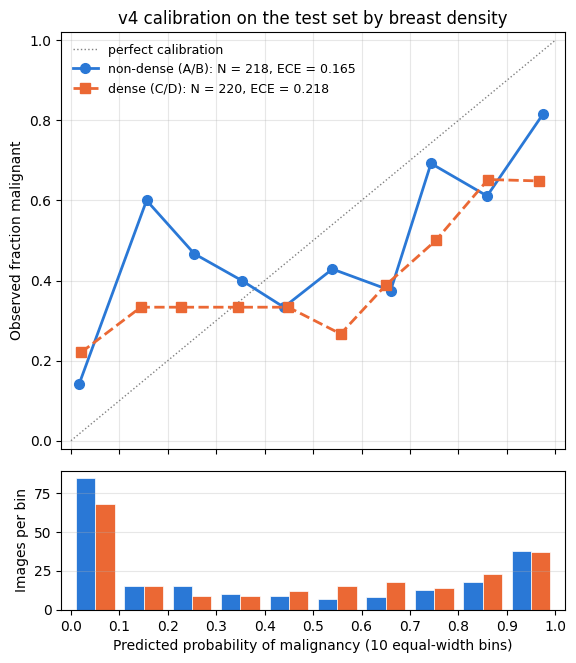


Saved -> /content/drive/MyDrive/MammoLens/original_split_with_recovered_images/figures/calibration_by_density.png


In [9]:
# 4.5 Sensitivity at a fixed specificity of 0.80, plus how well calibrated the probabilities are.
TARGET_SPEC = 0.80

def threshold_at_spec(y, p, target=TARGET_SPEC):
    neg = p[y == 0]
    for t in np.unique(np.r_[p, np.inf]):
        if np.mean(neg < t) >= target:
            return t

def rates(y, p, t):
    yhat = p >= t
    tp = int(np.sum(yhat & (y == 1))); fn = int(np.sum(~yhat & (y == 1)))
    tn = int(np.sum(~yhat & (y == 0))); fp = int(np.sum(yhat & (y == 0)))
    return tn / (tn + fp), tp / (tp + fn), tp, fn, tn, fp

val4 = add_group(PRED4['val'])
test_sets = {'all': test4, AB: G4[AB], CD: G4[CD]}
val_sets = {'all': val4, AB: val4[val4['group'] == AB], CD: val4[val4['group'] == CD]}
rows = []
for k in ('all', AB, CD):
    y, p = test_sets[k]['label'].to_numpy(), test_sets[k]['prob_malignant'].to_numpy()
    for source, fit in (('test-fitted', test_sets[k]), ('validation-fitted', val_sets[k])):
        t = threshold_at_spec(fit['label'].to_numpy(), fit['prob_malignant'].to_numpy())
        spec, sens, tp, fn, tn, fp = rates(y, p, t)
        rows.append({'stratum': k, 'threshold source': source, 'threshold': t,
                     'test specificity': spec, 'test sensitivity': sens,
                     'TP': tp, 'FN': fn, 'TN': tn, 'FP': fp})
        STAT_ROWS.append({'section': '4.5', 'stratum': k, 'metric': f'sensitivity at spec 0.80 ({source})',
                          'unit': '', 'value': sens, 'ci_low': np.nan, 'ci_high': np.nan})
op4 = pd.DataFrame(rows)
op4.to_csv(os.path.join(RES4, 'operating_points.csv'), index=False)
print(op4.to_string(index=False, formatters={'threshold': '{:.6f}'.format,
                                             'test specificity': '{:.3f}'.format,
                                             'test sensitivity': '{:.3f}'.format}))

EDGES = np.linspace(0, 1, 11)
def reliability(y, p):
    b = np.digitize(p, EDGES[1:-1])
    t = pd.DataFrame({'bin': [f'{EDGES[i]:.1f}-{EDGES[i + 1]:.1f}' for i in range(10)],
                      'n': [int(np.sum(b == i)) for i in range(10)],
                      'mean_pred': [p[b == i].mean() if np.any(b == i) else np.nan for i in range(10)],
                      'frac_malignant': [y[b == i].mean() if np.any(b == i) else np.nan for i in range(10)]})
    return t, np.nansum(t['n'] / len(y) * (t['frac_malignant'] - t['mean_pred']).abs())

STYLE = {AB: dict(color='#2a78d6', marker='o', linestyle='-'),
         CD: dict(color='#eb6834', marker='s', linestyle='--')}
fig, (ax, axn) = plt.subplots(2, 1, figsize=(6.5, 7.5), sharex=True,
                              gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})
ax.plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=1, label='perfect calibration')
for j, k in enumerate((AB, CD)):
    tab, ece = reliability(G4[k]['label'].to_numpy(), G4[k]['prob_malignant'].to_numpy())
    STAT_ROWS.append({'section': '4.5', 'stratum': k, 'metric': 'ECE', 'unit': '',
                      'value': ece, 'ci_low': np.nan, 'ci_high': np.nan})
    ok = tab['n'] > 0
    ax.plot(tab.loc[ok, 'mean_pred'], tab.loc[ok, 'frac_malignant'], linewidth=2, markersize=7,
            label=f'{k}: N = {len(G4[k])}, ECE = {ece:.3f}', **STYLE[k])
    axn.bar((EDGES[:-1] + EDGES[1:]) / 2 + (j - 0.5) * 0.04, tab['n'], width=0.04,
            color=STYLE[k]['color'], edgecolor='white', linewidth=0.5)
    print(f'\n{k}: ECE = {ece:.4f}')
    print(tab.to_string(index=False, formatters={'mean_pred': '{:.3f}'.format,
                                                 'frac_malignant': '{:.3f}'.format}))
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.set_ylabel('Observed fraction malignant')
ax.set_title('v4 calibration on the test set by breast density')
ax.legend(loc='upper left', fontsize=9, frameon=False)
ax.grid(alpha=0.3)
axn.set_ylabel('Images per bin'); axn.set_xlabel('Predicted probability of malignancy (10 equal-width bins)')
axn.set_xticks(EDGES); axn.grid(axis='y', alpha=0.3)
out = os.path.join(FIG4, 'calibration_by_density.png')
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved ->', out)

<a id="t6"></a>
**Table 6.** Sensitivity at a target specificity of 0.80 for v4, with the threshold fitted on the test set and on the validation set, followed by the per-bin calibration tables and the expected calibration error for each density group.

<a id="f2"></a>
**Figure 2.** Reliability diagram for v4: non-dense in blue circles with a solid line, dense in orange squares with a dashed line, ten equal-width bins, and the number of images per bin underneath. Saved as `original_split_with_recovered_images/figures/calibration_by_density.png`.

At a fixed specificity of 0.80 this model finds considerably more cancers than v3 did. With the threshold fitted on the test set, sensitivity is 0.542 overall against v3's 0.407, and within the groups it is 0.609 for non-dense and 0.517 for dense breasts, against v3's 0.433 and 0.326. The validation-fitted thresholds, which are the fairer estimate because they are not tuned on the data being scored, give 0.520 overall at a specificity of 0.846, and 0.554 and 0.506 by group. Those thresholds overshoot the target specificity, as they did in my earlier runs, because a few hundred validation images cannot pin a threshold down precisely.

Calibration is the best I have had, and still not good. The expected calibration error is 0.1654 for non-dense and 0.2182 for dense images, against 0.2292 and 0.2378 in v3. The shape of the problem has not changed: images given a probability below 0.1 turn out malignant in 0.141 of non-dense and 0.221 of dense cases, and the top bin only reaches 0.816 and 0.649 rather than something near 1. I would not present these probabilities as risk estimates.

<a id="s4-6"></a>
### 4.6 Grad-CAM gallery

The gallery uses the same selection rule as my earlier runs, so the galleries can be laid side by side: the three correctly classified malignant images with the highest predicted probability, the two most confident correct malignant calls from dense breasts that were not already picked, and the malignant image given the lowest probability. The map is computed for the malignant class at the last convolutional layer and masked to the breast, as before.

In v2 the maps mostly sat on the breast boundary rather than inside the tissue, which fitted that model's poor calibration and made me uneasy about what it had learned. Whether this model behaves differently is worth recording, though six cases picked for confidence cannot tell me what the model does in general.

Loaded v4 best_model.pt (epoch 11, val_auc 0.7641)
Cases: 3 high-conf, 2 dense, 1 failure


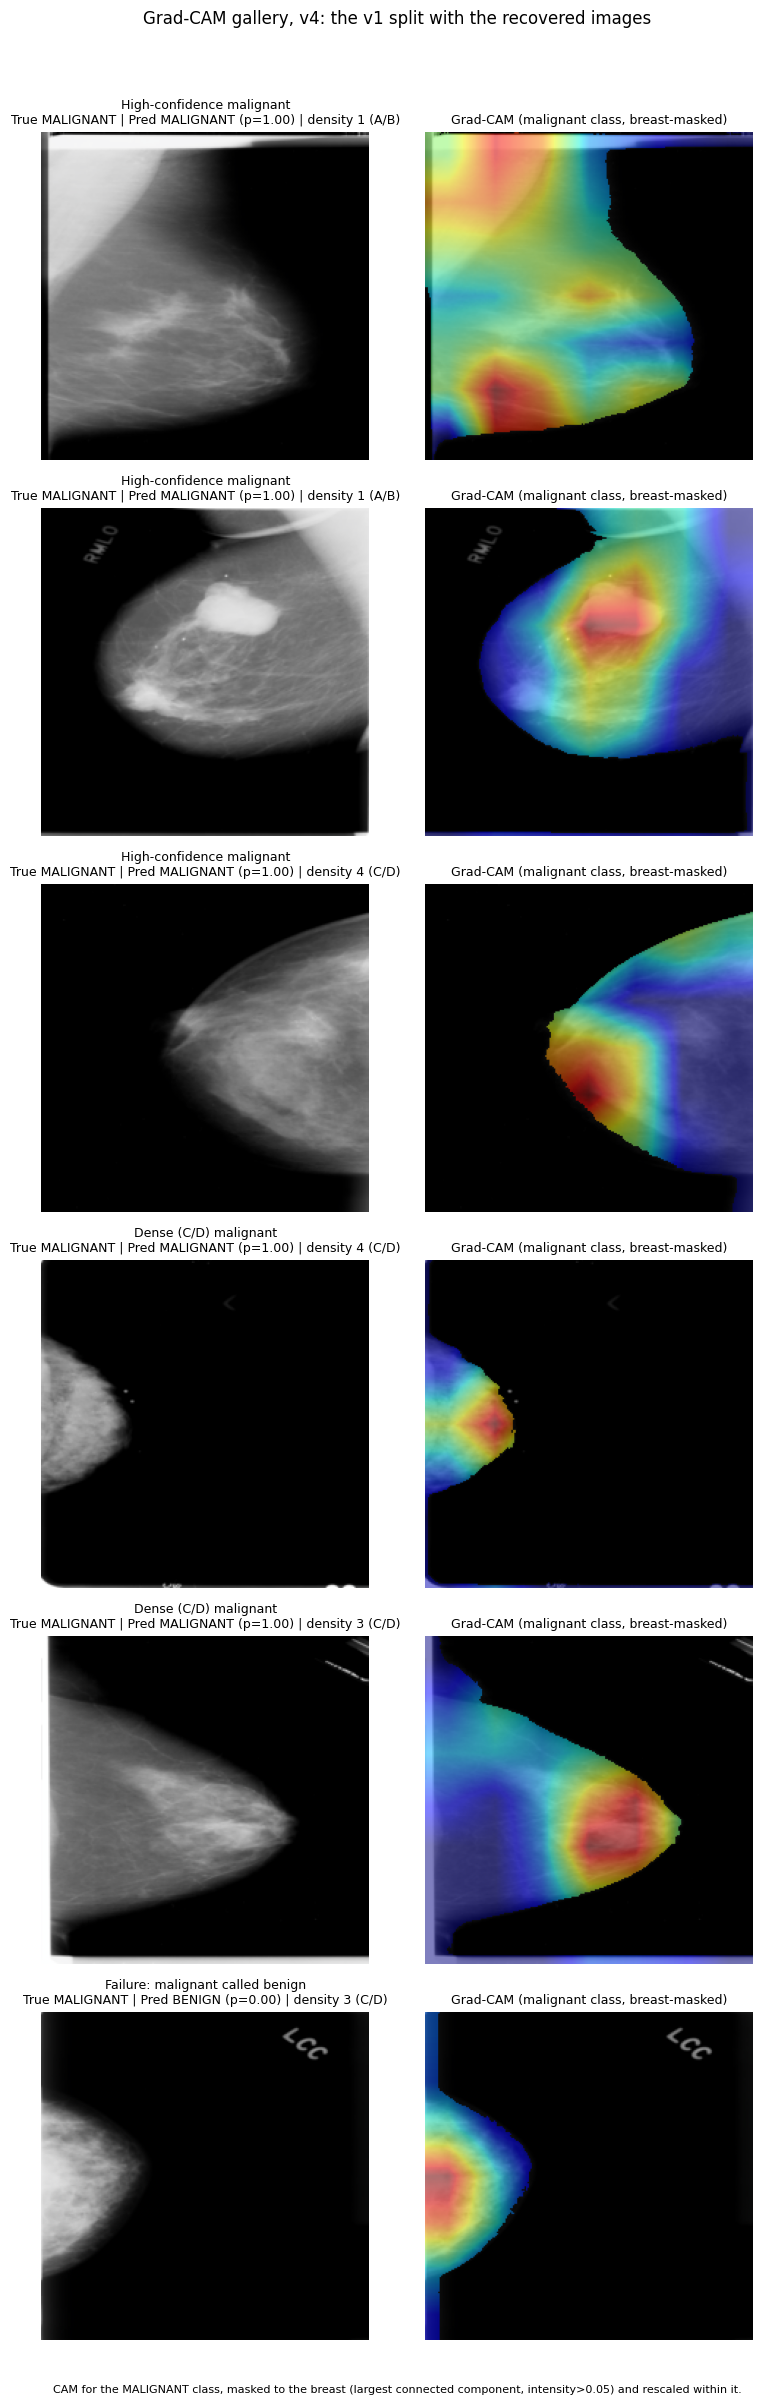

Saved -> /content/drive/MyDrive/MammoLens/original_split_with_recovered_images/figures/gradcam_gallery.png


In [10]:
# 4.6 Grad-CAM, using the same selection rule as my earlier runs so the galleries compare.
import matplotlib.cm as cm
from scipy import ndimage
from src.gradcam import GradCAM, last_conv_layer

MEAN = np.array([0.485, 0.456, 0.406]); STD = np.array([0.229, 0.224, 0.225])
MASK_THR = 0.05
ck = torch.load(os.path.join(CKPT4, 'best_model.pt'), map_location=device, weights_only=False)
cam_model = build_model(mcfg).to(device)
cam_model.load_state_dict(ck['model_state'])
cam_model.eval()
print(f"Loaded v4 best_model.pt (epoch {ck['epoch'] + 1}, val_auc {ck['best_auc']:.4f})")

df = PRED4['test'].copy()
df['pred'] = (df['prob_malignant'] >= 0.5).astype(int)
dgroup = lambda d: 'A/B' if d in (1, 2) else 'C/D'
correct_mal = df[(df.label == 1) & (df.pred == 1)].sort_values('prob_malignant', ascending=False)
sel_a = correct_mal.head(3)
sel_b = correct_mal[correct_mal.density.isin([3, 4]) & ~correct_mal.index.isin(sel_a.index)].head(2)
sel_c = df[(df.label == 1) & (df.pred == 0)].sort_values('prob_malignant').head(1)
selected = ([('High-confidence malignant', i) for i in sel_a.index]
            + [('Dense (C/D) malignant', i) for i in sel_b.index]
            + [('Failure: malignant called benign', i) for i in sel_c.index])
print(f'Cases: {len(sel_a)} high-conf, {len(sel_b)} dense, {len(sel_c)} failure')

cam_engine = GradCAM(cam_model, last_conv_layer(cam_model))
tf_eval = build_transforms(cfg4.data.image_size, train=False)
LBL = {0: 'BENIGN', 1: 'MALIGNANT'}
nrows = len(selected)
fig, axes = plt.subplots(nrows, 2, figsize=(8, 4 * nrows))
if nrows == 1:
    axes = axes[None, :]
for r, (tag, idx) in enumerate(selected):
    row = df.loc[idx]
    with Image.open(os.path.join(IMG_ROOT, row['image_path'])) as im:
        img_t = tf_eval(im.convert('RGB'))
    cam = cam_engine(img_t.unsqueeze(0).to(device), class_idx=POS)
    disp = np.clip(img_t.numpy().transpose(1, 2, 0) * STD + MEAN, 0, 1)
    gray = disp.mean(2)
    m = gray > MASK_THR
    lbl, n = ndimage.label(m)
    if n > 0:
        sizes = ndimage.sum(np.ones_like(lbl), lbl, range(1, n + 1))
        m = lbl == (np.argmax(sizes) + 1)
    cam_m = cam * m
    if cam_m.max() > 0:
        cam_m = cam_m / cam_m.max()
    heat = cm.jet(cam_m)[..., :3]
    overlay = disp.copy()
    overlay[m] = 0.5 * disp[m] + 0.5 * heat[m]
    axes[r, 0].imshow(disp); axes[r, 0].axis('off')
    axes[r, 0].set_title(f"{tag}\nTrue {LBL[row.label]} | Pred {LBL[row.pred]} "
                         f"(p={row.prob_malignant:.2f}) | density {row.density} ({dgroup(row.density)})",
                         fontsize=9)
    axes[r, 1].imshow(overlay); axes[r, 1].axis('off')
    axes[r, 1].set_title('Grad-CAM (malignant class, breast-masked)', fontsize=9)
fig.suptitle('Grad-CAM gallery, v4: the v1 split with the recovered images', fontsize=12, y=0.997)
fig.text(0.5, 0.004, f'CAM for the MALIGNANT class, masked to the breast (largest connected component, '
         f'intensity>{MASK_THR}) and rescaled within it.', ha='center', fontsize=8)
fig.tight_layout(rect=[0, 0.02, 1, 0.98])
out = os.path.join(FIG4, 'gradcam_gallery.png')
fig.savefig(out, dpi=160, bbox_inches='tight')
plt.show()
print('Saved ->', out)

<a id="f3"></a>
**Figure 3.** Grad-CAM gallery for v4, six test cases chosen by the same rule as my earlier runs. Left: the input after resizing, titled with the selection group, the true and predicted label, the predicted probability and the BI-RADS density. Right: the Grad-CAM map for the malignant class, masked to the breast. Saved as `original_split_with_recovered_images/figures/gradcam_gallery.png`.

This is the most encouraging gallery I have produced, with the caveat that six cases chosen for confidence cannot characterise a model. The rule filled all six slots from the epoch 11 checkpoint: three high-confidence correct malignant calls, two from dense breasts and one failure, with five probabilities of 1.00 and the failure at 0.00.

The second row is the clearest example of what I was hoping to see all along. The hot region sits squarely on the bright, well-defined mass in the middle of the breast, not on its outline. Rows 1 and 5 concentrate on interior fibroglandular tissue, and row 1 has two separate foci, one low and one high in the breast. Rows 3 and 4 still favour the anterior region near the nipple rather than any lesion I can point to, so the edge-following habit from v2 has not gone away entirely. The failure in row 6 is the same awkward type of case as before: the breast fills only a narrow strip of the frame next to a burnt-in view label, and the map covers it without settling anywhere.

Compared with v2, where most panels traced the breast boundary, this is a visible improvement, and it fits with the better discrimination and calibration. I am not going to call it evidence of localisation. I never compared these maps against the ROI masks the dataset provides, and saliency maps can look convincing while barely depending on the weights at all (Adebayo et al., 2018).

<a id="s5"></a>
## 5 Paired comparisons with v1 and v3

Each comparison uses only the images both runs held out, so neither model has trained on anything being scored, and the bootstrap resamples those images jointly for both models.

The two overlaps are very different sizes, and that shapes how much weight each one can carry. Because v4 inherits v1's partitions, those two test sets share nearly all of v1's images, and this is the comparison that answers my question. v4 and v3 were split differently, so their shared held-out set is small and that interval will be wide.

In [11]:
# STEP 4: paired differences, using only images both runs held out, so nothing was trained on.
def paired_ci(y, pa, pb, seed=SEED, n=N_BOOT):
    rng = np.random.default_rng(seed)
    out = []
    while len(out) < n:
        idx = rng.integers(0, len(y), len(y))
        if 0 < y[idx].sum() < len(idx):
            out.append(roc_auc_score(y[idx], pb[idx]) - roc_auc_score(y[idx], pa[idx]))
    return np.percentile(out, [2.5, 97.5])

rows = []
for name, other in (('v1', P1['test']), ('v3', P3['test'])):
    pair = (other[['image_path', 'label', 'prob_malignant']]
            .merge(PRED4['test'][['image_path', 'prob_malignant']], on='image_path',
                   suffixes=('_other', '_v4')))
    print(f'\nHeld out by both {name} and v4: {len(pair)} images '
          f'({len(other)} in the {name} test set, {len(PRED4["test"])} in v4)')
    if len(pair) < 20:
        print('  too few shared images for a paired comparison')
        continue
    y = pair['label'].to_numpy()
    pa, pb = pair['prob_malignant_other'].to_numpy(), pair['prob_malignant_v4'].to_numpy()
    auc_o, auc_4 = roc_auc_score(y, pa), roc_auc_score(y, pb)
    lo, hi = paired_ci(y, pa, pb)
    print(f'  {name} AUC {auc_o:.4f} | v4 AUC {auc_4:.4f} | paired difference (v4 minus {name}) '
          f'{auc_4 - auc_o:+.4f} [95% CI {lo:+.4f}, {hi:+.4f}]')
    rows.append({'comparison': f'v4 minus {name}', 'shared images': len(pair),
                 'malignant': int(y.sum()), f'AUC other': auc_o, 'AUC v4': auc_4,
                 'difference': auc_4 - auc_o, 'ci_low': lo, 'ci_high': hi})
    STAT_ROWS.append({'section': '5', 'stratum': f'shared with {name} (N={len(pair)})',
                      'metric': f'v4 minus {name} AUC', 'unit': 'paired',
                      'value': auc_4 - auc_o, 'ci_low': lo, 'ci_high': hi})
paired_tab = pd.DataFrame(rows)
paired_tab.to_csv(os.path.join(RES4, 'paired_comparisons.csv'), index=False)
print('\n' + paired_tab.to_string(index=False, float_format=lambda v: f'{v:.4f}'))


Held out by both v1 and v4: 400 images (400 in the v1 test set, 438 in v4)
  v1 AUC 0.7541 | v4 AUC 0.7501 | paired difference (v4 minus v1) -0.0041 [95% CI -0.0421, +0.0343]

Held out by both v3 and v4: 48 images (430 in the v3 test set, 438 in v4)
  v3 AUC 0.6626 | v4 AUC 0.7448 | paired difference (v4 minus v3) +0.0822 [95% CI -0.0789, +0.2500]

 comparison  shared images  malignant  AUC other  AUC v4  difference  ci_low  ci_high
v4 minus v1            400        169     0.7541  0.7501     -0.0041 -0.0421   0.0343
v4 minus v3             48         22     0.6626  0.7448      0.0822 -0.0789   0.2500


<a id="t7"></a>
**Table 7.** Paired AUC differences between v4 and v1, and between v4 and v3, each computed only on the images both runs held out, with the size of each overlap and a 95% bootstrap interval from jointly resampled images. Saved as `original_split_with_recovered_images/results/paired_comparisons.csv`.

The paired comparisons settle this as far as my design can.

Against v1, on the 400 images both runs held out, v1 scores 0.7541 and v4 scores 0.7501, a paired difference of -0.0041 with a 95% interval of [-0.0421, +0.0343]. On identical images the two models are indistinguishable. Adding 228 recovered images and 105 new patients to my original partitions neither helped nor hurt, at least at the resolution this test set gives me.

Against v3 the overlap is only 48 images, because v3 used the rebuilt split. On those, v3 scores 0.6626 and v4 scores 0.7448, a paired difference of +0.0822 with an interval of [-0.0789, +0.2500]. The point estimate is large and in the direction I expected, but 48 images give an interval that spans zero, so on its own this comparison supports the conclusion without establishing it. The stronger evidence for the same thing is the pair of aggregate figures on each run's own test set, 0.7527 against 0.6694, together with the fact that v3 and v4 trained on the same images with the same recipe.

There is one thing this cannot do, and I want to be straight about it. v4 differs from v3 both in what it trained on and in what it was tested on, so the loss could come from a harder rebuilt test set, from a validation set that led checkpoint selection astray, or from both at once. What I can say is that it does not come from the recovered data.

<a id="s6"></a>
## 6 Four-way comparison and what it supports

The table below puts all four of my runs on every metric I have reported. The rule for reading it was fixed before I ran anything: v4 close to v1 points at the re-split, v4 close to v3 points at the recovered images or the patients they brought, and anything in between gets reported as inconclusive.

Two limits hold whatever the numbers say. My v4 test set is built out of v1's, so those two runs are not independent samples and their agreement is weaker evidence than two separate draws would be. And every condition here is one training run with one seed, so differences of a few hundredths in AUC are inside the noise these test sets can resolve.

In [12]:
# STEP 5: all four of my runs on every metric I have reported.
def summarise(pred_by_split, seed=SEED):
    te = add_group(pred_by_split['test'])
    gA, gC = te[te['group'] == AB].reset_index(drop=True), te[te['group'] == CD].reset_index(drop=True)
    out = {}
    for s in ('train', 'val', 'test'):
        p = pred_by_split[s]
        out[f'{s} AUC'] = roc_auc_score(p['label'], p['prob_malignant'])
        out[f'{s} images'] = len(p)
        out[f'{s} patients'] = p['patient_id'].nunique()
    for name, d in (('all', te), (AB, gA), (CD, gC)):
        auc, sens, spec = point_metrics(d['label'].to_numpy(), d['prob_malignant'].to_numpy())
        out[f'AUC {name}'], out[f'sensitivity {name}'], out[f'specificity {name}'] = auc, sens, spec
        out[f'N {name}'] = len(d)
    bi = stratified_bootstrap(gA, gC, N_BOOT, seed, 'image')
    bp = stratified_bootstrap(gA, gC, N_BOOT, seed, 'patient')
    diff = out[f'AUC {AB}'] - out[f'AUC {CD}']
    lo_i, hi_i = np.percentile(bi[AB][:, 0] - bi[CD][:, 0], [2.5, 97.5])
    lo_p, hi_p = np.percentile(bp[AB][:, 0] - bp[CD][:, 0], [2.5, 97.5])
    _, p_i = z_test(diff, bi[AB][:, 0].std(ddof=1), bi[CD][:, 0].std(ddof=1))
    _, p_p = z_test(diff, bp[AB][:, 0].std(ddof=1), bp[CD][:, 0].std(ddof=1))
    out.update({'density gap (A/B minus C/D)': diff, 'gap CI low (image)': lo_i, 'gap CI high (image)': hi_i,
                'gap p (image)': p_i, 'gap CI low (patient)': lo_p, 'gap CI high (patient)': hi_p,
                'gap p (patient)': p_p})
    return out

S1, S2, S3, S4 = summarise(P1), summarise(P2), summarise(P3), summarise(PRED4)
four = pd.DataFrame([{'metric': k, 'v1': S1.get(k), 'v2': S2.get(k), 'v3': S3.get(k), 'v4': S4.get(k)}
                     for k in S4])
four['v4 minus v1'] = four['v4'] - four['v1']
four['v4 minus v3'] = four['v4'] - four['v3']
four.to_csv(os.path.join(RES4, 'v1_v2_v3_v4_comparison.csv'), index=False)
pd.DataFrame(STAT_ROWS).to_csv(os.path.join(RES4, 'stat_tests.csv'), index=False)
print(four.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

t_auc = {'v1': S1['test AUC'], 'v3': S3['test AUC'], 'v4': S4['test AUC']}
d1, d3 = abs(t_auc['v4'] - t_auc['v1']), abs(t_auc['v4'] - t_auc['v3'])
print(f"\nTest AUC: v1 {t_auc['v1']:.4f} | v3 {t_auc['v3']:.4f} | v4 {t_auc['v4']:.4f}")
print(f"v4 is {d1:.4f} from v1 and {d3:.4f} from v3 on their own test sets; "
      f"Table 7 gives the paired figures on shared images.")
print('\nSaved -> original_split_with_recovered_images/results/v1_v2_v3_v4_comparison.csv and stat_tests.csv')

                     metric        v1        v2        v3        v4  v4 minus v1  v4 minus v3
                  train AUC    0.9792    0.8960    0.9783    0.9709      -0.0084      -0.0074
               train images 2052.0000 2210.0000 2210.0000 2208.0000     156.0000      -2.0000
             train patients 1043.0000 1115.0000 1115.0000 1118.0000      75.0000       3.0000
                    val AUC    0.7554    0.7498    0.7504    0.7644       0.0090       0.0140
                 val images  405.0000  445.0000  445.0000  439.0000      34.0000      -6.0000
               val patients  208.0000  225.0000  225.0000  223.0000      15.0000      -2.0000
                   test AUC    0.7541    0.6627    0.6694    0.7527      -0.0014       0.0833
                test images  400.0000  430.0000  430.0000  438.0000      38.0000       8.0000
              test patients  209.0000  225.0000  225.0000  224.0000      15.0000      -1.0000
                    AUC all    0.7541    0.6627    0.6694   

<a id="t8"></a>
**Table 8.** All four runs on every metric, with v4's difference from v1 and from v3. Each run's test metrics are measured on its own test set, so Table 7 holds the comparisons made on shared images. Saved as `original_split_with_recovered_images/results/v1_v2_v3_v4_comparison.csv`.

Table 8 puts the four runs side by side, and the answer to the question I built this experiment for is the first of my two candidates: **the loss came from re-splitting the data, not from the images I recovered.**

Three different framings say the same thing. My test AUC of 0.7527 is 0.0014 from v1's 0.7541 and 0.0833 above v3's 0.6694. On the 400 images v1 and v4 both held out, the paired difference is -0.0041 with an interval of [-0.0421, +0.0343], so the two models perform alike on identical data. And v3 and v4 trained on the same 3085 images with the same recipe and the same seed, differing only in how those images were divided, yet their test AUCs differ by 0.0833.

The rest of the table follows the same pattern. Non-dense AUC is 0.8006 here against 0.8188 in v1 and 0.7029 in v3, and dense AUC is 0.7060 against 0.6950 and 0.6356. Sensitivity at the default threshold is 0.6369, close to v1's 0.6568, where v3 sat at 0.4472. The density gap of 0.0945 falls between v1's 0.1238 and v3's 0.0673.

Three limits travel with this conclusion, and I would rather state them myself than have someone find them. My v4 test set contains all 400 of v1's test images plus 38 more, so those two runs are not independent samples and their agreement proves less than two separate draws would. Each condition is one training run with one seed, and the intervals here span roughly 0.09 in AUC, so anything smaller than that is beyond what I can resolve. And this finding is about my dataset and my split procedure: it says that `StratifiedGroupKFold` with a different set of patients gave me partitions on which the same recipe trains to a materially worse model, not that re-splitting is a bad idea in general. The mechanism I find most plausible, visible in Table 4 of my rebuild notebook, is that the rebuilt validation set had a malignant share eight points below its test set, which makes checkpoint selection unreliable. I have not proved that, and I am not going to claim it.

For the write-up, the practical upshot is simple: the recovered data are safe to use and I should use them. The model I report is the one trained on the complete dataset with my original partitions, which is this one.

<a id="s7"></a>
## 7 Verification that no earlier artefact was touched

The last cell re-fingerprints every file in `initial_run/`, `recovered_data_run/`, `recovered_data_full_schedule/` and the manifests in `data/`, and compares the result with the fingerprint from Section 1. Anything added, removed or changed gets listed and the cell fails. My v4 split manifests are written inside `original_split_with_recovered_images/manifests/` and `data/` keeps the v2 manifests untouched, so all four runs stay reproducible from what is on disk.

In [13]:
# 7 Prove I wrote nothing outside original_split_with_recovered_images/.
AFTER = fingerprint()
added = sorted(set(AFTER) - set(BEFORE))
removed = sorted(set(BEFORE) - set(AFTER))
changed = sorted(k for k in set(BEFORE) & set(AFTER) if BEFORE[k] != AFTER[k])
print(f'Files checked: {len(AFTER)} across {len(PROTECTED)} protected folders')
print(f'  added:   {added if added else "none"}')
print(f'  removed: {removed if removed else "none"}')
print(f'  changed: {changed if changed else "none"}')
assert not (added or removed or changed), 'this notebook modified an earlier artefact'
print('\nOK: the v1, v2 and v3 artefacts are byte-for-byte as they were before this run.')
print('v4 wrote:', {d: sorted(os.listdir(os.path.join(RUN4, d)))
                    for d in ('results', 'checkpoints', 'figures', 'manifests')})

Files checked: 50 across 4 protected folders
  added:   none
  removed: none
  changed: none

OK: the v1, v2 and v3 artefacts are byte-for-byte as they were before this run.
v4 wrote: {'results': ['logs', 'operating_points.csv', 'paired_comparisons.csv', 'stat_tests.csv', 'test_predictions.csv', 'test_predictions_final.csv', 'train_predictions.csv', 'train_predictions_final.csv', 'training_log.csv', 'v1_v2_v3_v4_comparison.csv', 'val_predictions.csv', 'val_predictions_final.csv'], 'checkpoints': ['best_model.pt', 'last_checkpoint.pt'], 'figures': ['calibration_by_density.png', 'gradcam_gallery.png', 'training_curve.png'], 'manifests': ['test.csv', 'train.csv', 'val.csv']}


The check passed. Of the 50 files I am tracking across `initial_run/`, `recovered_data_run/`, `recovered_data_full_schedule/` and the manifests in `data/`, none was added, removed or changed. Everything this run produced sits in `original_split_with_recovered_images/`, including its own split manifests, so all four runs can still be compared from disk without rerunning any of them.